# Telco Customer Churn Analysis

## Business Problem
Customer churn happens when customers stop using a company's services.

The goal of this project is to analyze customer data and identify factors associated with customer churn. 
The analysis will help identify customer groups with higher churn rates and possible opportunities to improve customer retention.

## Business Questions
1. What is the overall churn rate?
2. Which customer groups have higher churn rates?
3. Does contract type affect churn?
4. Is churn related to customer tenure?
5. Is churn related to monthly charges?
6. Which services are associated with higher churn?

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [107]:
df = pd.read_csv("telco.csv")

In [108]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
df.shape

(7043, 21)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [111]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Quality Check
Before starting the analysis, I checked the dataset for missing values, 
duplicate records, incorrect data types, and inconsistent values.

In [112]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [113]:
df["customerID"].duplicated().sum()

np.int64(0)

In [114]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [115]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [116]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [117]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [118]:
df["TotalCharges"].dtype

dtype('float64')

In [119]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [120]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [121]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [122]:
for column in df.select_dtypes(include="object").columns:
    print(column)
    print(df[column].unique())
    print()

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes']



## Exploratory Data Analysis

### 1. What is the overall churn rate?

The first step is to determine the overall percentage of customers who churned.

In [123]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [124]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

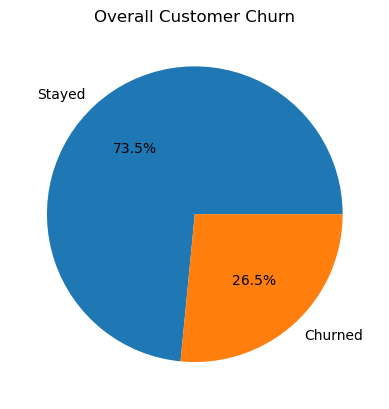

In [125]:
churn_rate.plot(
    kind="pie",
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%"
)

plt.title("Overall Customer Churn")
plt.ylabel("")
plt.show()

Approximately 26.5% of customers in the dataset churned, while 73.5% remained with the company.

### 2. Which customer groups have higher churn rates?
In this section, I analyze churn rates across basic customer characteristics, including gender,
senior citizen status, partner status, and dependents. Just a basic screening.

#### Gender
First, I compare churn rates between male and female customers.

In [126]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [127]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


The churn rate is very similar for male and female customers (26.2% vs. 26.9%),
suggesting that gender is not strongly associated with customer churn.

#### SeniorCitizen

In [ ]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

In [ ]:
Senior customers have a substantially higher churn rate (41.7%) compared to non-senior customers (23.6%).

#### Partner

In [ ]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

In [ ]:
Customers without a partner have a higher churn rate (33.0%) compared to customers with a partner (19.7%).

#### Dependents

In [ ]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

In [ ]:
Customers without dependents have a higher churn rate (31.3%) compared to customers with dependents (15.5%).

In [ ]:
customer_groups = pd.DataFrame({
    "Group": [
        "Female",
        "Male",
        "Non-Senior",
        "Senior",
        "No Partner",
        "Partner",
        "No Dependents",
        "Dependents"
    ],
    "ChurnRate": [
        26.9,
        26.2,
        23.6,
        41.7,
        33.0,
        19.7,
        31.3,
        15.5
    ]
})

In [ ]:
customer_groups

In [ ]:
customer_groups.plot(
    x="Group",
    y="ChurnRate",
    kind="bar",
    legend=False
)

plt.title("Churn Rate by Customer Characteristics")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### Customer Segmentation
The initial analysis showed higher churn rates among senior customers and customers without a partner. 
To explore this pattern further, I created customer segments combining senior citizen status and partner status.

In [ ]:
df["SeniorStatus"] = df["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

In [ ]:
df[["SeniorCitizen", "SeniorStatus"]].head()

In [ ]:
df[["SeniorCitizen", "SeniorStatus"]].value_counts()

In [ ]:
df["CustomerSegment"] = (
    df["SeniorStatus"] + " + " +
    df["Partner"].map({
        "No": "No Partner",
        "Yes": "Partner"
    })
)

In [ ]:
df[["SeniorCitizen", "Partner", "CustomerSegment"]].head(10)

In [ ]:
df["CustomerSegment"] = (
    df["SeniorStatus"] + " + " +
    df["Partner"].map({
        "No": "No Partner",
        "Yes": "Partner"
    })
)

In [ ]:
df[["SeniorStatus", "Partner", "CustomerSegment"]].head(10)

In [ ]:
df["CustomerSegment"].value_counts()

In [ ]:
pd.crosstab(
    df["CustomerSegment"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
segment_churn = pd.crosstab(
    df["CustomerSegment"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

In [ ]:
segment_churn

In [ ]:
segment_churn_sorted = segment_churn.sort_values()

In [ ]:
segment_churn_sorted.plot(kind="barh")

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Churn Rate (%)")
plt.ylabel("")
plt.show()

#### Key Finding
Churn varies substantially across customer groups. Senior customers and customers without a partner
or dependents have higher churn rates, while gender shows little difference.

Further segmentation showed that senior customers without a partner have the highest churn rate (48.9%),
while non-senior customers with a partner have the lowest churn rate (16.6%).

### 3. Does contract type affect churn?
In this section, I compare churn rates across different contract types to determine
whether contract length is associated with customer churn.

In [ ]:
df["Contract"].value_counts()

In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

In [ ]:
contract_churn

In [ ]:
contract_churn = contract_churn.reindex([
    "Month-to-month",
    "One year",
    "Two year"
])

In [ ]:
ax = contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers with shorter contracts have substantially higher churn rates. 
Month-to-month customers have the highest churn rate at 42.7%, 
compared to 11.3% for one-year contractsand only 2.8% for two-year contracts.

### 4. Is churn related to customer tenure?
In this section, I analyze whether customer tenure is associated with churn
and whether newer customers are more likely to leave the company.

In [ ]:
df.groupby("Churn")["tenure"].describe()

In [ ]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

In [ ]:
df[["tenure", "TenureGroup"]].head(10)

In [ ]:
df["TenureGroup"].value_counts().sort_index()

In [ ]:
pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

In [ ]:
tenure_churn

In [ ]:
ax = tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers with shorter tenure have substantially higher churn rates.
Customers in their first 12 months have the highest churn rate at 47.4%.
Churn decreases as tenure increases, reaching only 9.5% among customers who have been with the company for 49–72 months.

### 5. Is churn related to monthly charges?
In this section, I analyze whether monthly charges are associated with customer churn
and whether customers with higher monthly charges are more likely to leave the company.

In [ ]:
df.groupby("Churn")["MonthlyCharges"].describe()

In [ ]:
df["MonthlyCharges"].describe()

In [ ]:
df["ChargeGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [ ]:
df[["MonthlyCharges", "ChargeGroup"]].head(10)

In [ ]:
df["ChargeGroup"].value_counts().sort_index()

In [ ]:
pd.crosstab(
    df["ChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
charge_churn = pd.crosstab(
    df["ChargeGroup"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

In [ ]:
charge_churn

In [ ]:
ax = charge_churn.plot(kind="bar")

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

#### Key Finding
Customers with higher monthly charges generally have higher churn rates.
The churn rate increases from 11.2% in the Low charge group to 37.5% in the Medium-High group.
However, it decreases slightly to 32.9% in the High charge group,
suggesting that the relationship between monthly charges and churn is not strictly linear.

### 6. Which services are associated with higher churn?

In [ ]:
df["InternetService"].value_counts()

In [ ]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
df["OnlineSecurity"].value_counts()

In [ ]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
df["TechSupport"].value_counts()

In [ ]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

In [ ]:
internet_services = [
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies"
]

In [ ]:
service_churn = {}

for service in internet_services:
    rates = pd.crosstab(
        df[service],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
    
    service_churn[service] = {
        "No": rates["No"],
        "Yes": rates["Yes"]
    }

In [ ]:
service = "OnlineSecurity"

In [ ]:
df[service]

In [ ]:
service_churn_df = pd.DataFrame(service_churn).T

In [ ]:
service_churn_df

In [ ]:
ax = service_churn_df.plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Churn Rate by Internet Add-on Services")
plt.xlabel("Churn Rate (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

ax.invert_yaxis()

plt.show()

In [ ]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

In [ ]:
internet_churn

In [ ]:
internet_churn = internet_churn.reindex([
    "No",
    "DSL",
    "Fiber optic"
])

In [ ]:
ax = internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

#### Key Finding
Fiber optic customers have the highest churn rate among internet service types at 41.9%,
compared to 19.0% for DSL customers and 7.4% for customers without internet service.

Among internet add-on services, customers without Online Security or Tech Support have substantially higher churn rates
than customers with these services. Online Backup and Device Protection also show noticeable differences,
while Streaming TV and Streaming Movies show relatively small differences in churn.

## Overall Key Findings
- The overall customer churn rate is 26.5%.
    
- Customer characteristics are associated with different churn rates.
Senior customers, customers without a partner, and customers without dependents have higher churn rates.
The highest churn rate among the analyzed customer segments was observed for senior customers without a partner at 48.9%.

- Contract type shows a strong association with churn.
Month-to-month customers have a churn rate of 42.7%, compared to 11.3% for one-year contracts and 2.8% for two-year contracts.

- Customer tenure is also strongly associated with churn.
Customers in their first 12 months have the highest churn rate at 47.4%,
while customers with 49–72 months of tenure have a churn rate of only 9.5%.

- Higher monthly charges are generally associated with higher churn, although the relationship is not strictly linear.
Among internet services, Fiber optic customers have a high churn rate of 41.9%.
Customers without Online Security or Tech Support also show substantially higher churn rates than customers with these services.

## Business Recommendations
- Encourage month-to-month customers to switch to longer-term contracts by offering incentives,
such as discounts or additional benefits.

- Focus on customer retention during the first year.
Customers with less than 12 months of tenure have the highest churn rate,
so the company could improve onboarding and offer additional support or incentives to new customers.

- Pay additional attention to customer groups with higher churn rates, especially senior customers without a partner.
The company could further investigate why these customers are more likely to leave and test targeted retention strategies.

- Consider promoting Online Security and Tech Support services. Customers without these services have substantially higher churn rates.
The company could test whether offering these services as part of a package or promotion helps improve customer retention.

- Investigate the high churn rate among Fiber optic customers.
Since 41.9% of Fiber optic customers churned, the company should examine possible reasons,
such as pricing, service quality, or customer experience, before deciding on a specific retention strategy.

- Contact customers before their contracts expire and consider offering renewal incentives to encourage them to stay.

## Conclusion
This analysis identified several customer characteristics associated with higher churn.
The strongest patterns were found among month-to-month customers, customers with shorter tenure,
and Fiber optic customers. Higher churn rates were also observed among customers without Online Security or Tech Support.

These findings can help the company identify higher-risk customer groups and develop targeted retention strategies.
Further analysis could explore the relationships between these factors and test which retention strategies are most effective.